In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt

### Tabela de elementos
Carrega de `elementos-ondas.txt` os comprimentos de onda tabelados de Kα e Kβ de cada elemento.

In [2]:
filename = 'elementos-ondas.txt'

with open(filename, 'r') as file:
    lines = file.readlines()

parsed_data = [line.split() for line in lines]

elements = []
ka = []
kb = []

for line in parsed_data:
    if len(line) >= 3:
        elements.append(line[1])
        ka.append(float(line[2]))
        if len(line) > 3:
            kb.append(float(line[3]))
        else:
            kb.append(np.nan)

elements_array = np.array(elements)
ka_array = np.array(ka)
kb_array = np.array(kb)

### Conversão pela lei de Bragg
Para cada ângulo medido, o comprimento de onda é obtido pela lei de Bragg com n = 1:

`λ = 2d · sen(ângulo / 2)`, com o ângulo convertido de graus para radianos.

O valor de `2d` depende do grupo analisado:

- `2d = 4.028` — Ti-U e K,Ca,Sn-Cs
- `2d = 6.53` — Cl, S, P
- `2d = 8.742` — Si, Al
- `2d = 25.75` — Mg, Na, F, O

Cada grupo (arquivo de dados, ponto inicial, número de pontos, `2d`, faixa angular e nomes de saída) é descrito na lista `GROUPS`.

In [3]:
def angular_axis(start, n):
    return np.arange(start, start + n * 0.1, 0.1)[:n]


def bragg(axis, two_d):
    return two_d * np.sin((axis * math.pi / 180) / 2)


GROUPS = [
    {'name': 'Ti-U',     'file': 'Ti-U.txt',     'start': 10.0,  'n': 801, 'two_d': 4.028, 'range': (10.0, 90.0),   'output_ka': 'picosKaTi-U',     'output_kb': 'picosKbTi-U',     'plot_kb': True},
    {'name': 'KCaSn-Cs', 'file': 'KCaSn-Cs.txt', 'start': 90.0,  'n': 501, 'two_d': 4.028, 'range': (90.0, 140.0),  'output_ka': 'picosKaKCaSn-Cs', 'output_kb': 'picosKbKCaSn-Cs', 'plot_kb': True},
    {'name': 'Cl',       'file': 'Cl.txt',       'start': 90.0,  'n': 61,  'two_d': 6.53,  'range': (90.0, 96.0),   'output_ka': 'picosKaCl',       'output_kb': 'picosKbCl',       'plot_kb': False},
    {'name': 'S',        'file': 'S.txt',        'start': 108.0, 'n': 61,  'two_d': 6.53,  'range': (108.0, 114.0), 'output_ka': 'picosKaS.csv',    'output_kb': 'picosKbS.csv',    'plot_kb': False},
    {'name': 'P',        'file': 'P.txt',        'start': 138.0, 'n': 61,  'two_d': 6.53,  'range': (138.0, 144.0), 'output_ka': 'picosKaP.csv',    'output_kb': 'picosKbP.csv',    'plot_kb': False},
    {'name': 'Si',       'file': 'Si.txt',       'start': 106.0, 'n': 61,  'two_d': 8.742, 'range': (106.0, 112.0), 'output_ka': 'picosKaSi.csv',   'output_kb': 'picosKbSi.csv',   'plot_kb': False},
    {'name': 'Al',       'file': 'Al.txt',       'start': 142.0, 'n': 61,  'two_d': 8.742, 'range': (142.0, 148.0), 'output_ka': 'picosKaAl.csv',   'output_kb': 'picosKbAl.csv',   'plot_kb': False},
    {'name': 'Mg',       'file': 'Mg.txt',       'start': 42.0,  'n': 61,  'two_d': 25.75, 'range': (42.0, 48.0),   'output_ka': 'picosKaMg.csv',   'output_kb': 'picosKbMg.csv',   'plot_kb': True},
    {'name': 'Na',       'file': 'Na.txt',       'start': 52.0,  'n': 61,  'two_d': 25.75, 'range': (52.0, 58.0),   'output_ka': 'picosKaN.csv',    'output_kb': 'picosKbN.csv',    'plot_kb': False},
    {'name': 'F',        'file': 'F.txt',        'start': 88.0,  'n': 61,  'two_d': 25.75, 'range': (88.0, 94.0),   'output_ka': 'picosKaF.csv',    'output_kb': 'picosKbF.csv',    'plot_kb': False},
    {'name': 'O',        'file': 'O.txt',        'start': 130.0, 'n': 61,  'two_d': 25.75, 'range': (130.0, 136.0), 'output_ka': 'picosKaO.csv',    'output_kb': 'picosKbO.csv',    'plot_kb': False},
]

### Casamento com Kα/Kβ
`find_matches`: percorre os λ calculados e registra os pontos cujo valor está próximo (tolerância `atol = 0.04`) de um Kα/Kβ tabelado.

In [4]:
def find_matches(wavelengths, data, k_array, angles):
    candidates = []
    for value, angle, intensity in zip(wavelengths, angles, data):
        for j, tabulated in enumerate(k_array):
            if np.isclose(value, tabulated, atol=0.04):
                candidates.append((value, round(angle, 2), elements_array[j], intensity))
                break
    return candidates

### Filtragem e verificação de picos
`filter_peaks`: para cada elemento, mantém apenas o candidato de maior intensidade.

`verify_peaks`: confirma como pico os pontos que são máximos locais (intensidade maior que a dos vizinhos imediatos). O critério é simples e ainda pode gerar falsos positivos.

In [5]:
def filter_peaks(candidates):
    max_by_element = {}
    for value, angle, element, intensity in candidates:
        if (element not in max_by_element) or (intensity > max_by_element[element][3]):
            max_by_element[element] = (value, angle, element, intensity)
    return np.array(list(max_by_element.values()))


def find_index(position, total_points, min_value, max_value):
    return ((position - min_value) / (max_value - min_value) * (total_points - 1))


def verify_peaks(peaks, data, min_value, max_value):
    real_peaks = []
    n = len(data)
    for row in peaks:
        peak = float(row[3])
        peak_position = float(row[1])
        element = row[2]
        j = int(find_index(peak_position, n, min_value, max_value))
        if j > 0 and peak == data[j - 1]:
            j = j - 1
        if j < n - 1 and peak == data[j + 1]:
            j = j + 1
        previous = data[j - 1] if j > 0 else np.inf
        following = data[j + 1] if j < n - 1 else np.inf
        if (peak > previous) and (peak > following):
            real_peaks.append((peak, peak_position, element))
    return real_peaks

In [6]:
results = {}
for group in GROUPS:
    data = np.loadtxt(group['file'])
    axis = angular_axis(group['start'], group['n'])
    wavelengths = bragg(axis, group['two_d'])
    min_value, max_value = group['range']

    candidates_ka = filter_peaks(find_matches(wavelengths, data, ka_array, axis))
    candidates_kb = filter_peaks(find_matches(wavelengths, data, kb_array, axis))
    peaks_ka = np.array(verify_peaks(candidates_ka, data, min_value, max_value))
    peaks_kb = np.array(verify_peaks(candidates_kb, data, min_value, max_value))

    np.savetxt(group['output_ka'], peaks_ka, delimiter=',', fmt='%s')
    np.savetxt(group['output_kb'], peaks_kb, delimiter=',', fmt='%s')

    results[group['name']] = {'axis': axis, 'data': data, 'Ka': peaks_ka, 'Kb': peaks_kb}

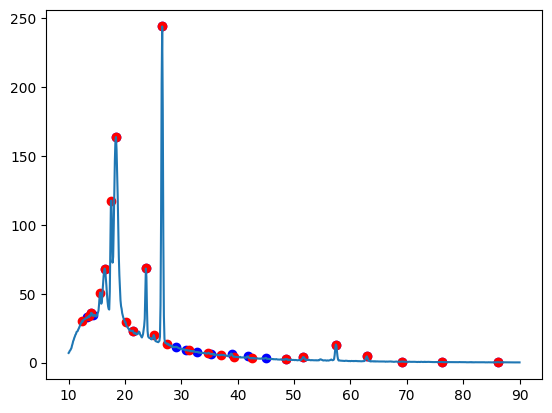

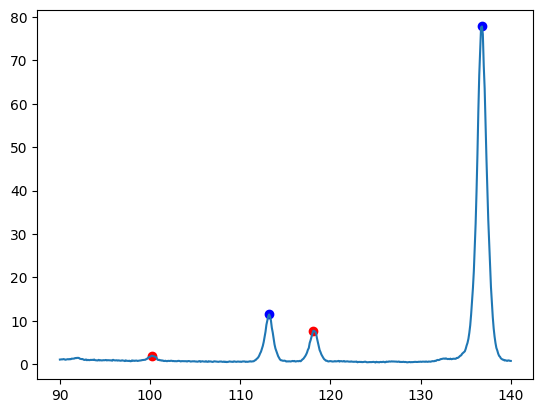

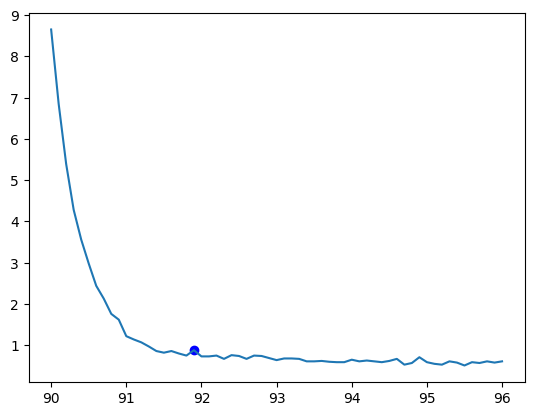

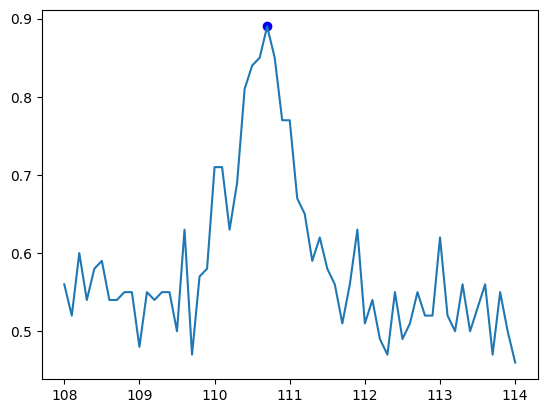

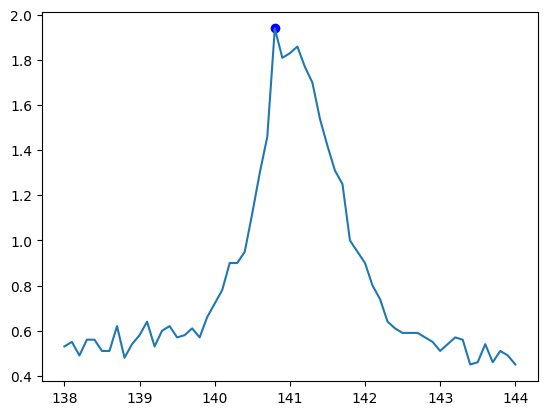

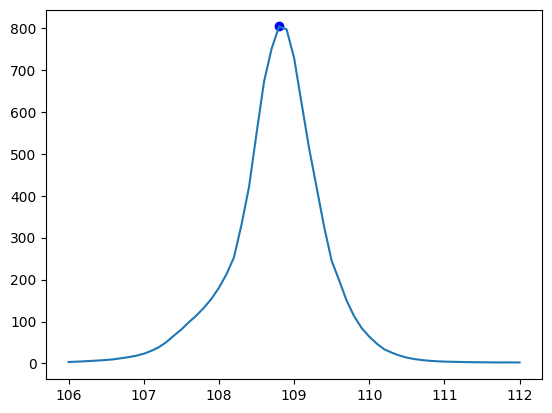

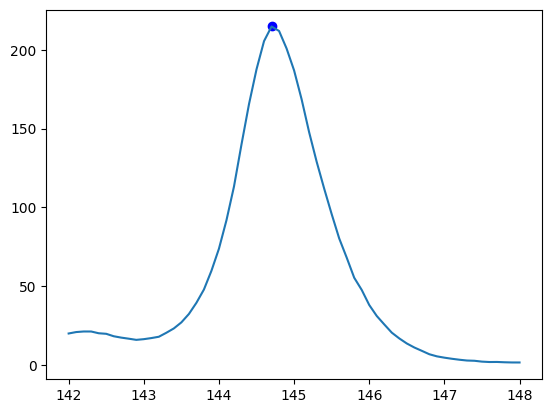

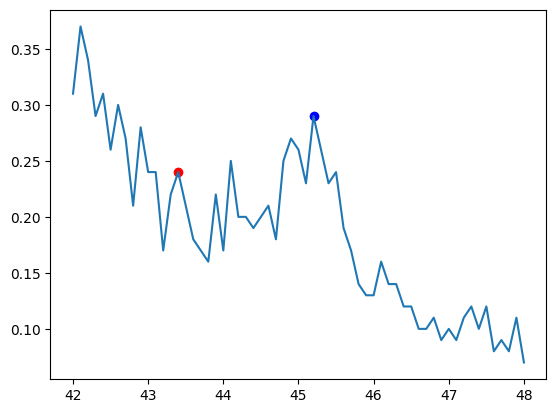

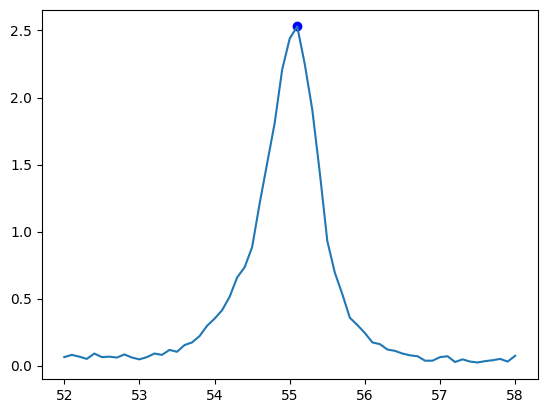

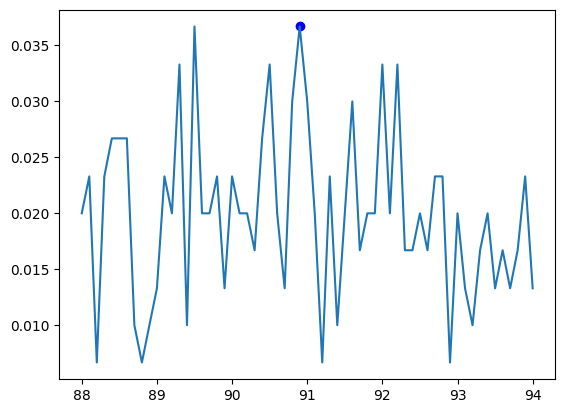

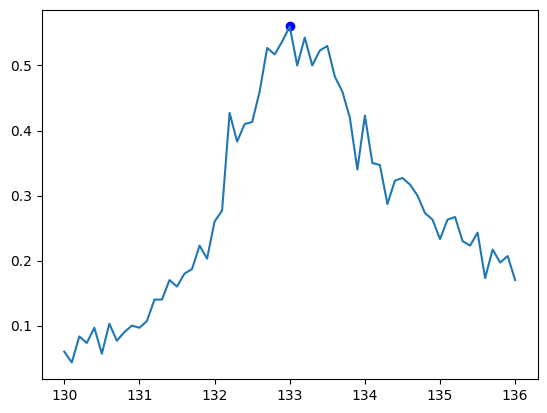

In [7]:
for group in GROUPS:
    result = results[group['name']]
    peaks_ka = result['Ka']
    peaks_kb = result['Kb']
    if len(peaks_ka):
        plt.plot(peaks_ka[:, 1].astype(float), peaks_ka[:, 0].astype(float), marker='o', linestyle='', color='blue')
    if group['plot_kb'] and len(peaks_kb):
        plt.plot(peaks_kb[:, 1].astype(float), peaks_kb[:, 0].astype(float), marker='o', linestyle='', color='red')
    plt.plot(result['axis'], result['data'])
    plt.show()